# Global Tech Startups 2026 Analysis

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

## Data loading

In [2]:
df= pd.read_csv('../data/global_tech_startups_2026.csv')

In [3]:
df.head()

,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
0,B730AD52,HealthTech,2014,Canada,Montreal,Seed,1.64,17.81,1.46,0.33,3.8,23,0,23,Tier 3 (Angel/Seed),High,Independent
1,65A5F690,Web3/Crypto,2014,China,Beijing,Pre-IPO,103.87,949.16,32.77,2.42,41.2,242,146,96,Tier 3 (Angel/Seed),NaN,Closed
2,F106C853,Cybersecurity,2020,USA,San Francisco,Series A,10.08,43.37,2.16,1.01,9.1,59,0,59,Tier 2 (Mid-size VC),High,Independent
3,2BD798AF,FinTech,2023,India,Delhi NCR,Series B,32.28,257.62,11.66,0.78,36.7,76,0,76,Tier 3 (Angel/Seed),Medium,Independent
4,C5CB4451,Generative AI,2020,USA,New York,Series C+,13.41,76.73,2.57,1.12,11.0,59,28,31,Tier 2 (Mid-size VC),Medium,Closed


In [4]:
print('Dataset shape: {} rows, {} columns'.format(df.shape[0], df.shape[1]))

Dataset shape: 25000 rows, 17 columns


## Data cleaning

In [5]:
print('Any duplicates? ', df.duplicated().any())

Any duplicates?  False


In [6]:
missing_values = df.isna().sum()

print('Missing values: ')
print(missing_values)

Missing values: 
Company_ID                       0
Domain                           0
Founding_Year                    0
Country                          0
City                             0
Funding_Stage                    0
Total_Funding_USD_Millions       0
Valuation_USD_Millions           0
Revenue_ARR_Millions             0
Monthly_Burn_Rate_Millions       0
Runway_Months_2024               0
Peak_Headcount_2023              0
Layoffs_2024_2025                0
Current_Headcount_2026           0
Investor_Tier                    0
AI_Adoption_Level             2592
Acquisition_Status               0
dtype: int64


In [7]:
df.isna().mean() * 100

Company_ID                     0.000
Domain                         0.000
Founding_Year                  0.000
Country                        0.000
City                           0.000
Funding_Stage                  0.000
Total_Funding_USD_Millions     0.000
Valuation_USD_Millions         0.000
Revenue_ARR_Millions           0.000
Monthly_Burn_Rate_Millions     0.000
Runway_Months_2024             0.000
Peak_Headcount_2023            0.000
Layoffs_2024_2025              0.000
Current_Headcount_2026         0.000
Investor_Tier                  0.000
AI_Adoption_Level             10.368
Acquisition_Status             0.000
dtype: float64

In [8]:
df.loc[df['AI_Adoption_Level'].isna()].head(10)

,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
1,65A5F690,Web3/Crypto,2014,China,Beijing,Pre-IPO,103.87,949.16,32.77,2.42,41.2,242,146,96,Tier 3 (Angel/Seed),NaN,Closed
11,B976C5FE,Web3/Crypto,2020,USA,Seattle,Series A,29.70,106.15,6.46,1.45,19.2,133,60,73,Corporate VC (e.g. Google Ventures),NaN,Acquired
40,7153735A,Generative AI,2023,India,Delhi NCR,Series A,8.63,41.98,1.47,0.51,14.1,36,11,25,Tier 3 (Angel/Seed),NaN,Closed
51,5C40C7E2,Cybersecurity,2020,India,Mumbai,Seed,1.80,26.41,3.73,0.62,2.5,46,18,28,Tier 3 (Angel/Seed),NaN,Independent
58,83C88D10,Generative AI,2020,USA,New York,Series A,9.94,39.88,2.50,0.60,14.2,54,11,43,Tier 2 (Mid-size VC),NaN,Independent
87,20C6131E,ClimateTech,2019,UK,London,Seed,0.53,16.59,0.70,0.17,2.0,14,6,8,Tier 3 (Angel/Seed),NaN,Closed
92,7F757D38,Cybersecurity,2019,Canada,Vancouver,Seed,1.36,29.07,1.20,0.18,4.9,12,0,12,Tier 3 (Angel/Seed),NaN,Closed
105,BAA1AFA1,Robotics,2023,India,Mumbai,Seed,1.06,20.50,3.76,0.08,5.9,7,2,5,Corporate VC (e.g. Google Ventures),NaN,Independent
118,0FDAFED6,Autonomous Vehicles,2020,USA,New York,Series B,36.50,331.43,11.93,1.84,18.8,173,40,133,Tier 3 (Angel/Seed),NaN,Independent
129,E61203D5,FinTech,2014,China,Shenzhen,Series A,13.46,112.67,17.29,0.79,15.1,48,7,41,Corporate VC (e.g. Google Ventures),NaN,Independent


The missing values do not need to be removed for this project.

In [9]:
df.dtypes

Company_ID                     object
Domain                         object
Founding_Year                   int64
Country                        object
City                           object
Funding_Stage                  object
Total_Funding_USD_Millions    float64
Valuation_USD_Millions        float64
Revenue_ARR_Millions          float64
Monthly_Burn_Rate_Millions    float64
Runway_Months_2024            float64
Peak_Headcount_2023             int64
Layoffs_2024_2025               int64
Current_Headcount_2026          int64
Investor_Tier                  object
AI_Adoption_Level              object
Acquisition_Status             object
dtype: object

In [10]:
cols = ['Total_Funding_USD_Millions', 'Valuation_USD_Millions', 'Revenue_ARR_Millions', 'Monthly_Burn_Rate_Millions']

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    ((df[cols] < (Q1 - 1.5 * IQR)) |
     (df[cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]

outliers.head()

,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
1,65A5F690,Web3/Crypto,2014,China,Beijing,Pre-IPO,103.87,949.16,32.77,2.42,41.2,242,146,96,Tier 3 (Angel/Seed),NaN,Closed
5,22994DE8,Generative AI,2014,China,Shanghai,Series A,287.28,2399.01,190.65,5.00,56.3,500,0,500,Tier 3 (Angel/Seed),Low,Independent
19,B2864A7D,Robotics,2021,USA,Seattle,Series C+,74.17,661.86,69.86,2.85,25.1,263,0,263,Tier 2 (Mid-size VC),High,Independent
24,C80FA4EA,HealthTech,2018,USA,Boston,Series A,114.78,392.42,18.74,4.05,27.7,292,0,292,"Tier 1 (e.g. Sequoia, a16z)",Low,Independent
29,439B6205,Generative AI,2018,USA,Boston,Pre-IPO,459.27,4002.12,512.91,11.62,39.2,710,0,710,Tier 2 (Mid-size VC),Low,Independent


In [11]:
print('Outliers found: ', outliers.shape[0])

Outliers found:  4540


Considering that this dataset is synthetic and that there is no specific research questions from the author of this dataset, the outliers in this project are not to be removed and are to be treated as legitimate.

## Exploratory Data Analysis

### Is AI adoption level associated with changes in startup headcount between peak 2023 and current 2026?

In [12]:
cat_cols = df.select_dtypes('object').columns.tolist()
cat_cols.remove('Company_ID')
cat_cols

['Domain',
 'Country',
 'City',
 'Funding_Stage',
 'Investor_Tier',
 'AI_Adoption_Level',
 'Acquisition_Status']

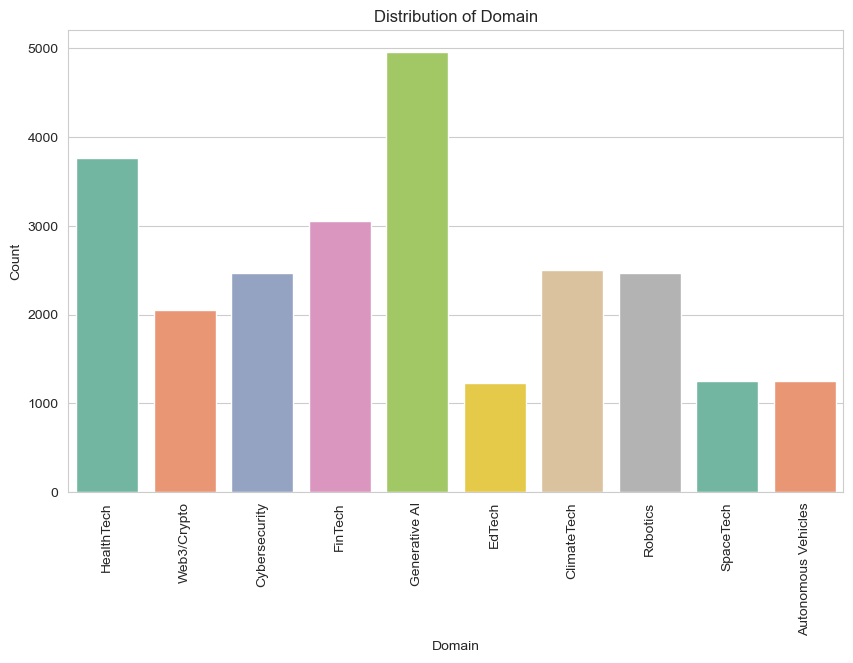

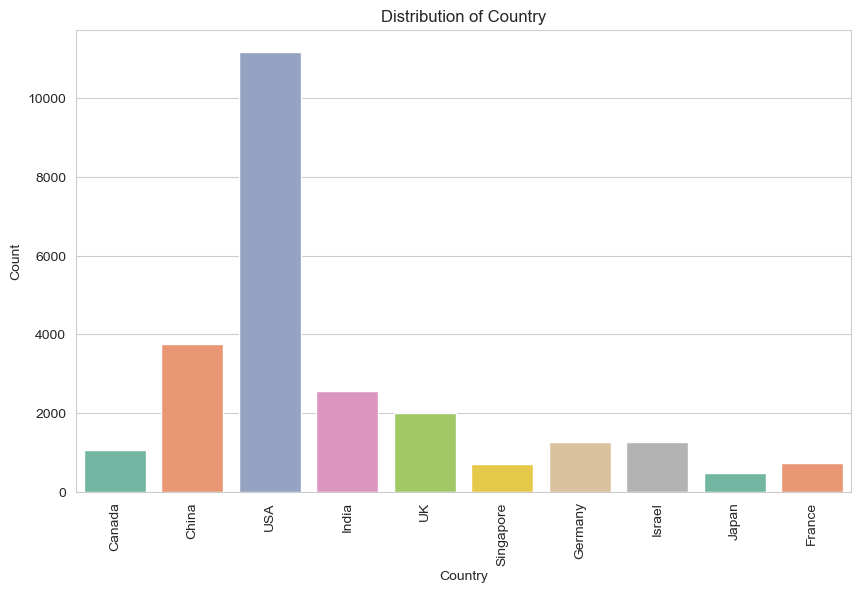

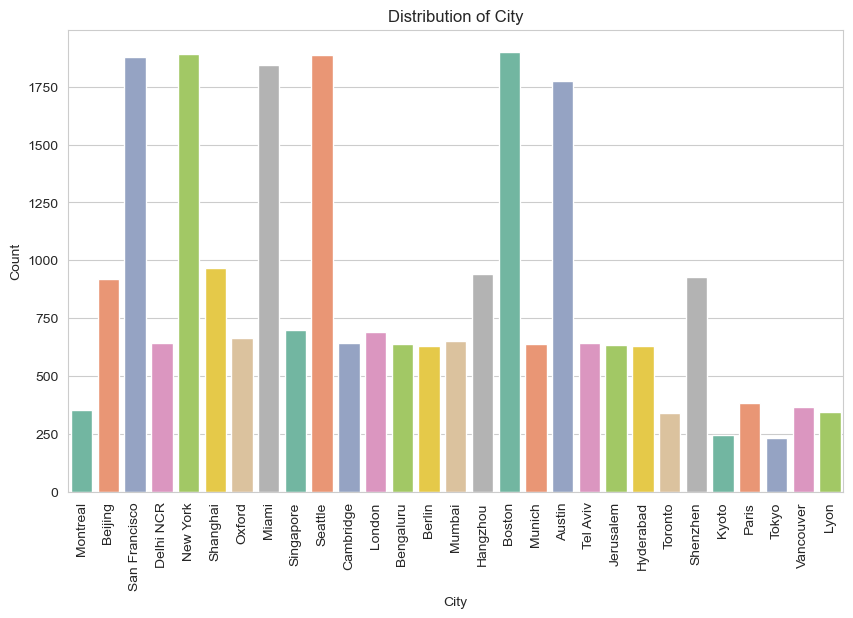

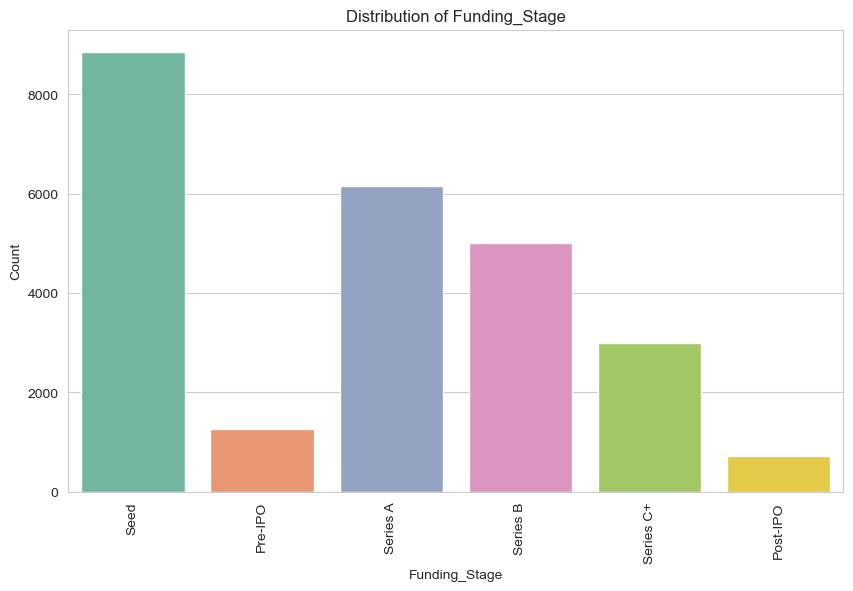

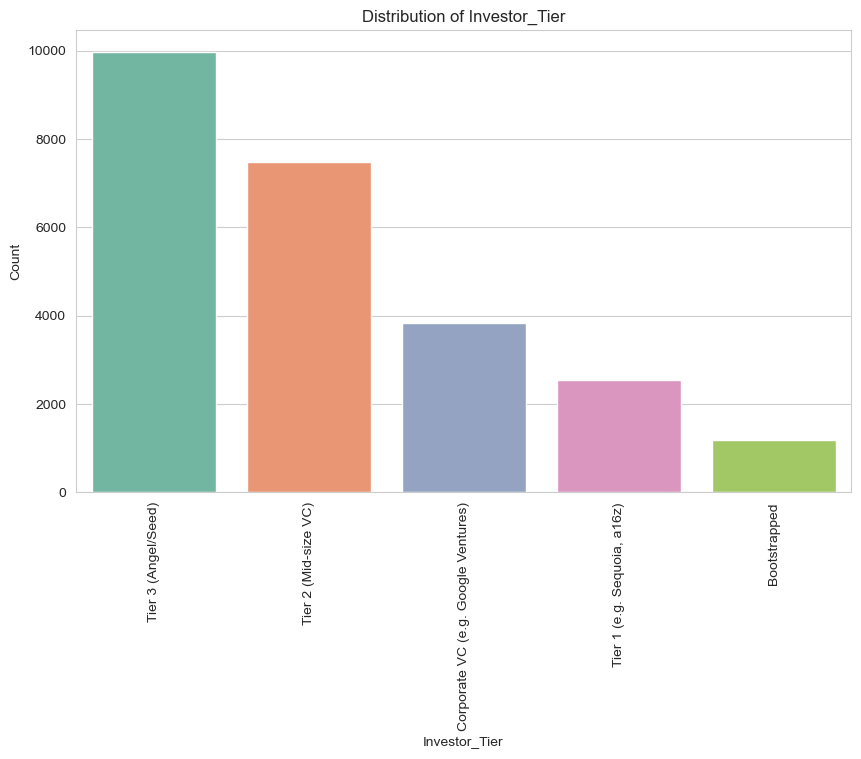

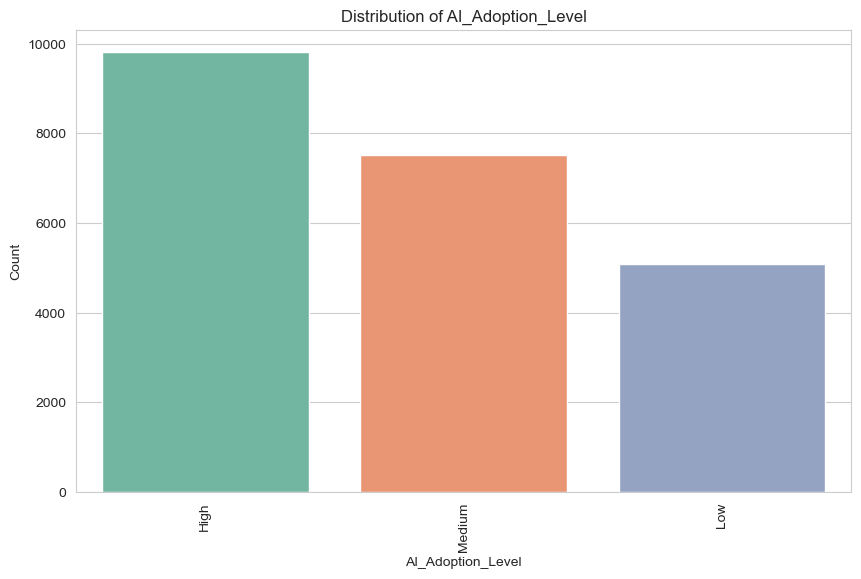

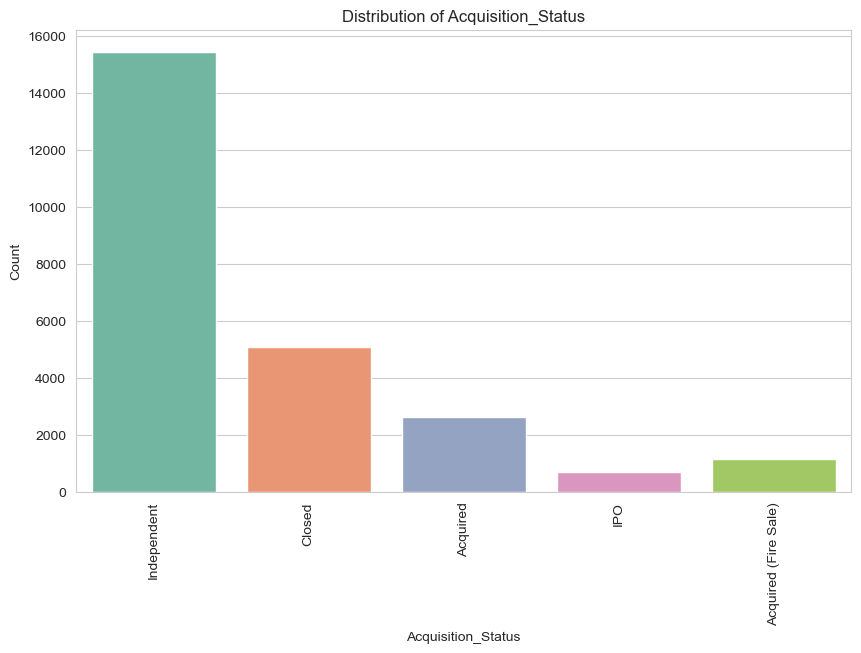

In [13]:
sns.set_style('whitegrid')

for col in df[cat_cols]:
    plt.figure(figsize=(10, 6))
    
    sns.countplot(data=df, x=col, palette='Set2')
    
    plt.title(f'Distribution of {col}')
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.show()

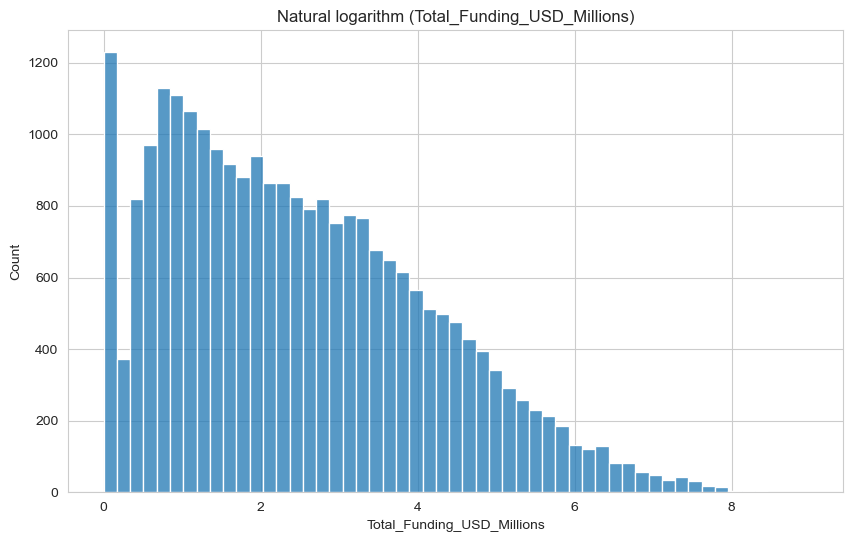

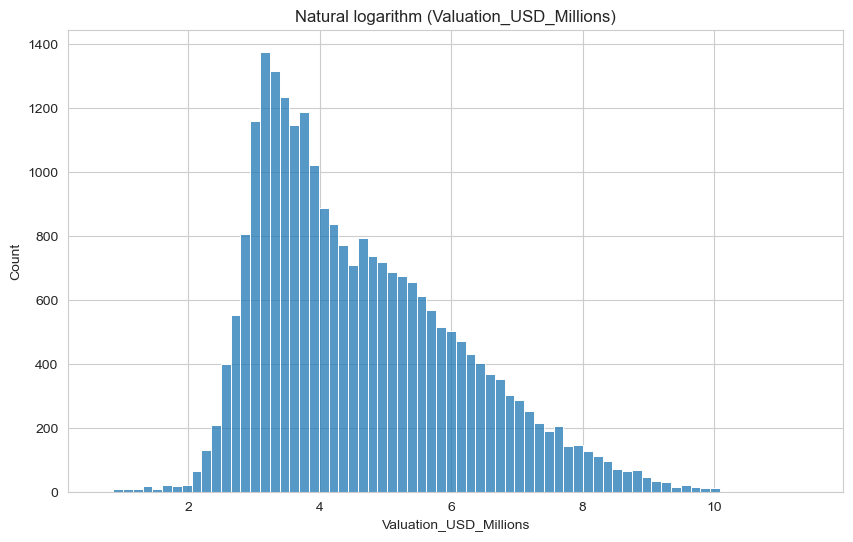

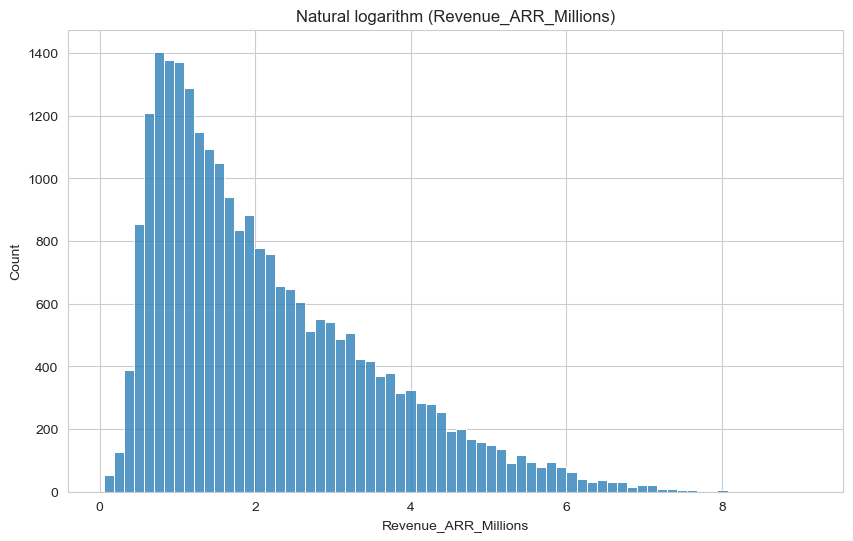

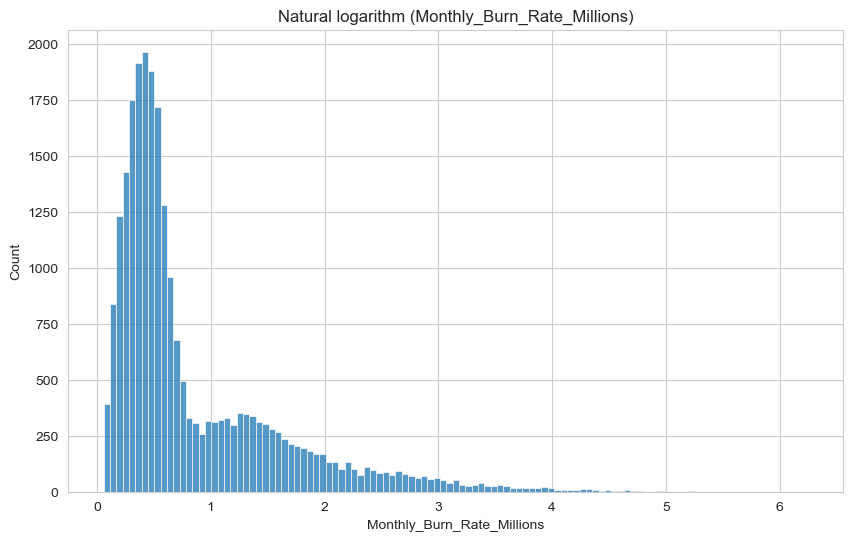

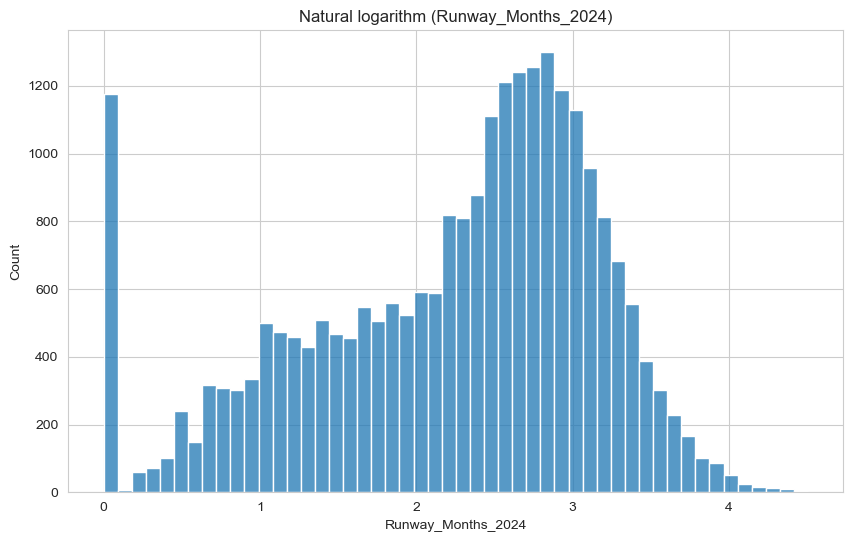

In [14]:
num_cols = df.select_dtypes('float64', 'int64').columns.tolist()

for col in df[num_cols]:
    plt.figure(figsize=(10, 6))
    
    sns.histplot(x=np.log1p(df[col]))
    
    plt.title(f'Natural logarithm ({col})')
    
    plt.show()

In [15]:
df['AI_Adoption_Level'].value_counts()

AI_Adoption_Level
High      9814
Medium    7512
Low       5082
Name: count, dtype: int64

In [16]:
df['AI_Adoption_Level'].value_counts(normalize=True).mul(100)

AI_Adoption_Level
High      43.796858
Medium    33.523742
Low       22.679400
Name: proportion, dtype: float64

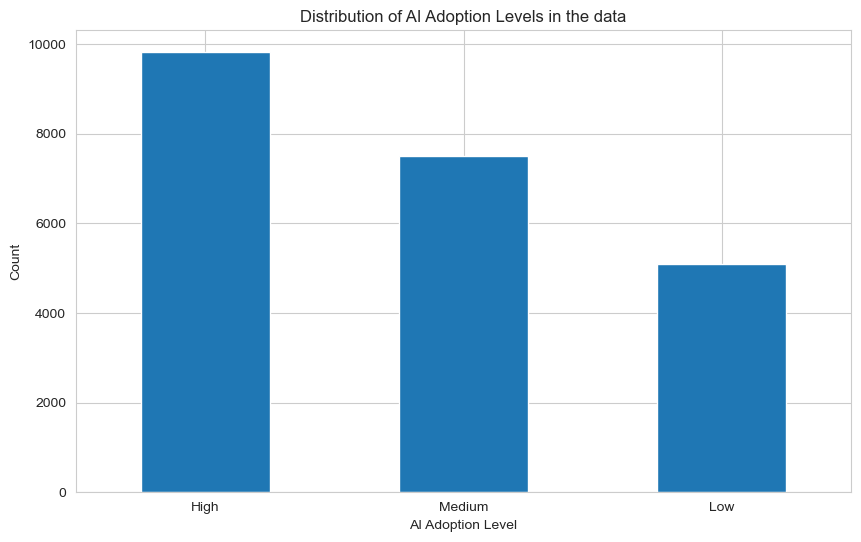

In [17]:
df['AI_Adoption_Level'].value_counts().plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Distribution of AI Adoption Levels in the data')
plt.xlabel('AI Adoption Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [18]:
df['Founding_Year'].value_counts().sort_index()

Founding_Year
2012     492
2013     761
2014    1236
2015    1317
2016    1239
2017    1293
2018    2592
2019    3685
2020    5047
2021    3671
2022    1727
2023    1239
2024     444
2025     257
Name: count, dtype: int64

In [19]:
print('Least recent company founded in', df['Founding_Year'].min())

print('Most recent company founded in', df['Founding_Year'].max())

Least recent company founded in 2012
Most recent company founded in 2025


In [20]:
df.groupby(['Founding_Year', 'AI_Adoption_Level']).size()

Founding_Year  AI_Adoption_Level
2012           High                  203
               Low                    96
               Medium                148
2013           High                  309
               Low                   163
               Medium                214
2014           High                  458
               Low                   252
               Medium                392
2015           High                  532
               Low                   270
               Medium                380
2016           High                  478
               Low                   252
               Medium                376
2017           High                  515
               Low                   258
               Medium                387
2018           High                 1058
               Low                   546
               Medium                753
2019           High                 1485
               Low                   711
               Medium   

In [21]:
adoption_by_year = pd.crosstab(
    df['Founding_Year'],
    df['AI_Adoption_Level'],
    normalize='index'
) * 100

adoption_by_year

AI_Adoption_Level,High,Low,Medium
Founding_Year,,,
2012,45.413870,21.476510,33.109620
2013,45.043732,23.760933,31.195335
2014,41.560799,22.867514,35.571688
2015,45.008460,22.842640,32.148900
2016,43.218807,22.784810,33.996383
2017,44.396552,22.241379,33.362069
2018,44.887569,23.165040,31.947391
2019,45.068285,21.578149,33.353566
2020,43.525499,23.281596,33.192905


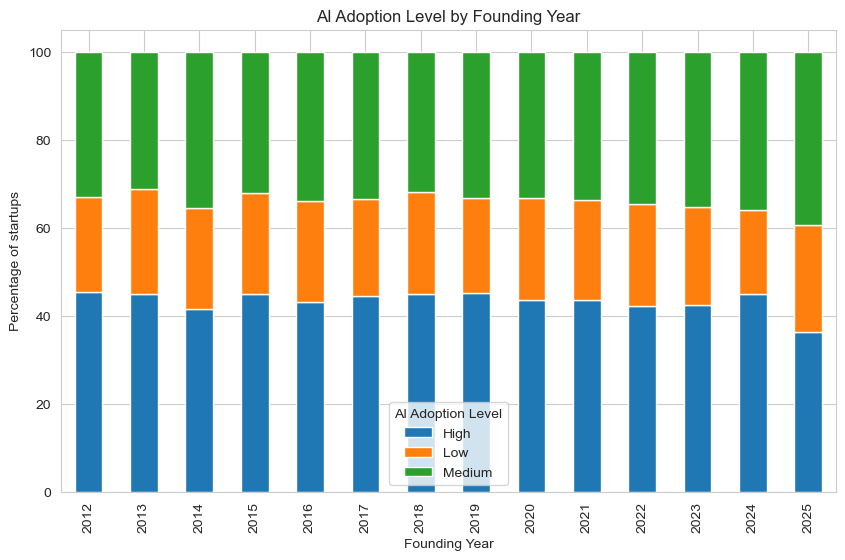

In [22]:
adoption_by_year.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('AI Adoption Level by Founding Year')
plt.xlabel('Founding Year')
plt.ylabel('Percentage of startups')
plt.legend(title='AI Adoption Level')
plt.show()

The bar chart shows that the AI adoption level has not changed much when comparing 2012 and 2025.

In [23]:
df['Headcount_Change_Pct'] = (
    df['Layoffs_2024_2025'] /
    df['Peak_Headcount_2023']
) * 100

In [24]:
df[
    [
        'Peak_Headcount_2023',
        'Current_Headcount_2026',
        'Layoffs_2024_2025',
        'Headcount_Change_Pct'
    ]
].head(10)

,Peak_Headcount_2023,Current_Headcount_2026,Layoffs_2024_2025,Headcount_Change_Pct
0,23,23,0,0.000000
1,242,96,146,60.330579
2,59,59,0,0.000000
3,76,76,0,0.000000
4,59,31,28,47.457627
5,500,500,0,0.000000
6,32,32,0,0.000000
7,18,18,0,0.000000
8,95,95,0,0.000000
9,127,127,0,0.000000


In [25]:
df[
    [
        'Peak_Headcount_2023',
        'Current_Headcount_2026',
        'Layoffs_2024_2025',
        'Headcount_Change_Pct'
    ]
].describe()

,Peak_Headcount_2023,Current_Headcount_2026,Layoffs_2024_2025,Headcount_Change_Pct
count,25000.000000,25000.000000,25000.000000,25000.000000
mean,211.739920,180.176600,31.563320,16.565118
std,693.946443,606.174385,175.987811,23.590042
min,5.000000,0.000000,0.000000,0.000000
25%,30.000000,22.000000,0.000000,0.000000
50%,48.000000,42.000000,0.000000,0.000000
75%,154.000000,119.000000,16.000000,35.360800
max,30086.000000,25657.000000,10280.000000,100.000000


In [26]:
(df['Peak_Headcount_2023'] <= 0).sum()

0

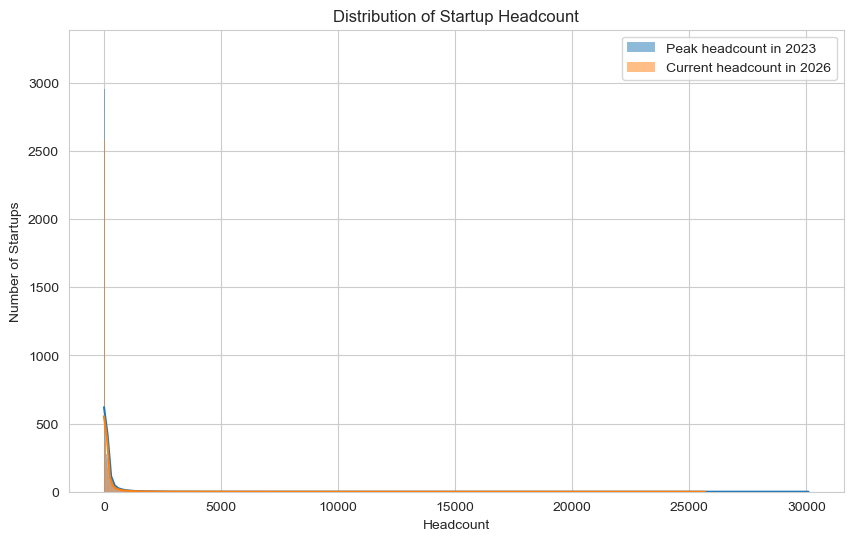

In [27]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['Peak_Headcount_2023'],
    kde=True,
    label='Peak headcount in 2023',
    alpha=0.5
)

sns.histplot(
    df['Current_Headcount_2026'],
    kde=True,
    label='Current headcount in 2026'
)

plt.title('Distribution of Startup Headcount')
plt.xlabel('Headcount')
plt.ylabel('Number of Startups')
plt.legend()
plt.show()

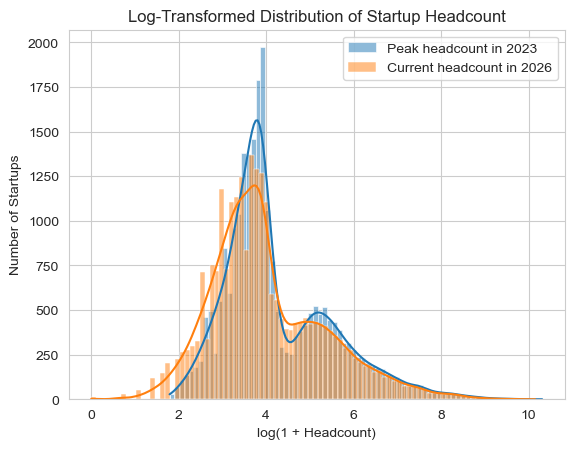

In [28]:
sns.histplot(
    np.log1p(df['Peak_Headcount_2023']),
    kde=True,
    label='Peak headcount in 2023',
    alpha=0.5
)

sns.histplot(
    np.log1p(df['Current_Headcount_2026']),
    kde=True,
    label='Current headcount in 2026',
    alpha=0.5
)

plt.title('Log-Transformed Distribution of Startup Headcount')
plt.xlabel('log(1 + Headcount)')
plt.ylabel('Number of Startups')
plt.legend()
plt.show()

In [29]:
def classify_change(x):
    if x < 0:
        return 'Increased'
    elif x > 0:
        return 'Decreased'
    else:
        return 'No change'

The explanation for x < 0 indicating an increase is because the Layoffs_2024_2025 variable, whenever there is a positive value, would mean that layoffs have happened and therefore the headcount has decreased.

In [30]:
df['Headcount_Direction'] = (
    df['Layoffs_2024_2025'].apply(classify_change)
)

In [31]:
df['Headcount_Direction'].value_counts()

Headcount_Direction
No change    15290
Decreased     9710
Name: count, dtype: int64

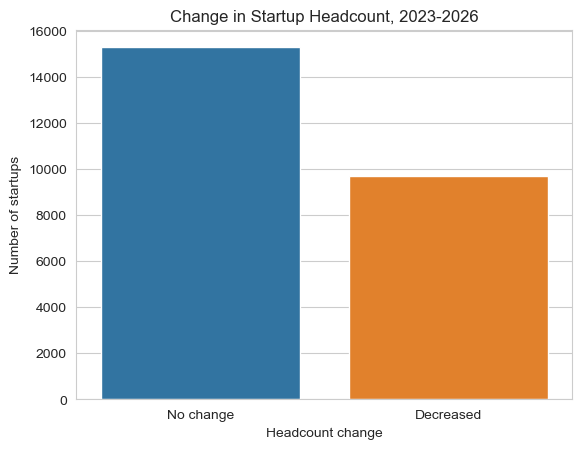

In [32]:
sns.countplot(data=df, x='Headcount_Direction')

plt.title('Change in Startup Headcount, 2023-2026')
plt.xlabel('Headcount change')
plt.ylabel('Number of startups')
plt.show()

In [33]:
df.groupby('AI_Adoption_Level')[
    'Headcount_Change_Pct'
].agg(
    ['count', 'mean', 'median', 'std']
)

,count,mean,median,std
AI_Adoption_Level,,,,
High,9814,16.536214,0.0,23.488517
Low,5082,16.271989,0.0,23.585715
Medium,7512,16.771321,0.0,23.712317


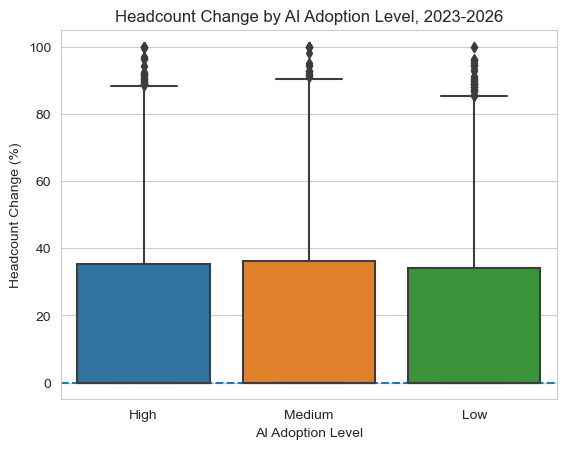

In [34]:
sns.boxplot(data=df, x='AI_Adoption_Level', y='Headcount_Change_Pct')

plt.axhline(0, linestyle='--')

plt.title('Headcount Change by AI Adoption Level, 2023-2026')
plt.xlabel('AI Adoption Level')
plt.ylabel('Headcount Change (%)')
plt.show()

There does not seem to be a significant change because the mean and the standard are around the same and the median is the same across all levels of AI adoption. This may indicate that the headcount change is not caused by how much a startup uses AI.

In [35]:
headcount_direction = pd.crosstab(
    df['AI_Adoption_Level'],
    df['Headcount_Direction'],
    normalize='index'
) * 100

headcount_direction

Headcount_Direction,Decreased,No change
AI_Adoption_Level,,
High,38.944365,61.055635
Low,38.134593,61.865407
Medium,39.084132,60.915868


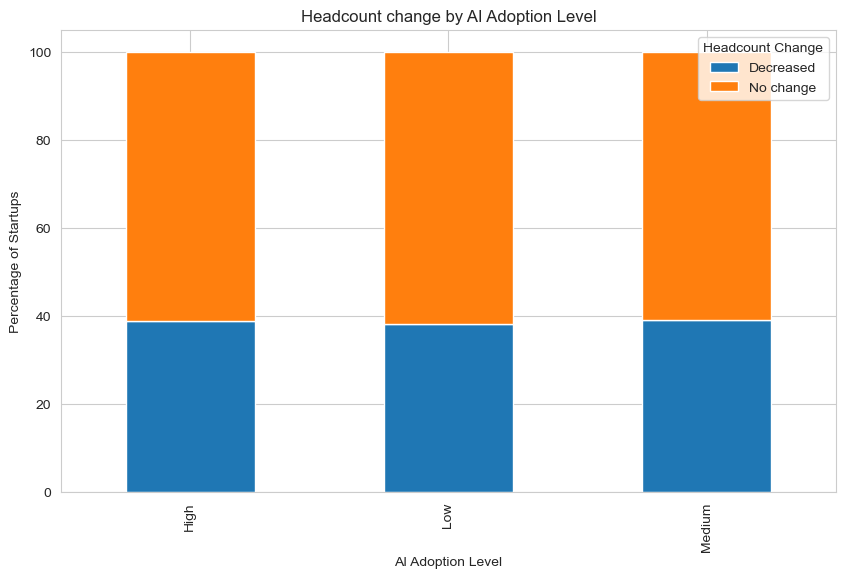

In [36]:
headcount_direction.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Headcount change by AI Adoption Level')
plt.xlabel('AI Adoption Level')
plt.ylabel('Percentage of Startups')
plt.legend(title='Headcount Change')
plt.show()

Because Headcount_Change_Pct distribution appears heavily concentrated at 0, and is not particularly suitable for assuming normality, a Kruskal-Wallis test should be applied.

In [37]:
from scipy.stats import kruskal

high = df[df['AI_Adoption_Level'] == 'High']['Headcount_Change_Pct']
medium = df[df['AI_Adoption_Level'] == 'Medium']['Headcount_Change_Pct']
low = df[df['AI_Adoption_Level'] == 'Low']['Headcount_Change_Pct']

stat, p = kruskal(high, medium, low)

print('Kruskal-Wallis statistic: ', stat)
print('p-value: ', p)

Kruskal-Wallis statistic:  1.6508967192822939
p-value:  0.43803854962280164


The H0 hypothesis is that the distribution of headcount change is the same across the three AI adoption levels.
The  H1 hypothesis is that at least one AI adoption group has a different distribution.
In this case, the p-value is greater than 0.05, so reject H1 hypothesis.
Having both a descriptive analysis (via the boxplot) and inferential evidence, we can conclude that there is no statistically significant evidence between AI adoption level and headcount percentage change.

In [38]:
pd.crosstab(
    df['AI_Adoption_Level'],
    df['Headcount_Direction'],
    normalize='index'
) * 100

Headcount_Direction,Decreased,No change
AI_Adoption_Level,,
High,38.944365,61.055635
Low,38.134593,61.865407
Medium,39.084132,60.915868


The **size** of the headcount change was tested, but a chi-square test can be performed to see whether the **decrease** outcome in headcount is associated with AI adoption level.

In [39]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df['AI_Adoption_Level'],
    df['Headcount_Direction']
)

chi2, p, dof, expected = chi2_contingency(table)

print('Chi-square statistic: ', chi2)
print('p-value: ', p)
print('Degrees of freedom: ', dof)

Chi-square statistic:  1.2885028901797957
p-value:  0.5250554278585674
Degrees of freedom:  2


There is an insufficient evidence of an association between AI adoption level and whether a startup experienced a headcount decrease.

### Are other company characteristics associated with headcount change?

In [40]:
print('Rows: ', len(df))
print('Unique companies: ', df['Company_ID'].nunique())
print('Duplicate companies: ', df['Company_ID'].duplicated().sum())

Rows:  25000
Unique companies:  24999
Duplicate companies:  1


During data cleaning, the duplicate company ID was not detected when looking for duplicate records.

In [41]:
df[df['Company_ID'].duplicated(keep=False)].sort_values('Company_ID')

,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status,Headcount_Change_Pct,Headcount_Direction
17524,7791E581,Generative AI,2018,Israel,Jerusalem,Seed,7.56,61.03,2.15,0.46,13.5,40,0,40,Tier 3 (Angel/Seed),NaN,Independent,0.0,No change
23398,7791E581,HealthTech,2020,USA,New York,Seed,0.72,15.77,1.67,0.82,0.8,49,0,49,Tier 3 (Angel/Seed),Medium,Independent,0.0,No change


In [42]:
missing = df.isna().sum().sort_values(ascending=False)
print(missing)

AI_Adoption_Level             2592
Company_ID                       0
Runway_Months_2024               0
Headcount_Change_Pct             0
Acquisition_Status               0
Investor_Tier                    0
Current_Headcount_2026           0
Layoffs_2024_2025                0
Peak_Headcount_2023              0
Monthly_Burn_Rate_Millions       0
Domain                           0
Revenue_ARR_Millions             0
Valuation_USD_Millions           0
Total_Funding_USD_Millions       0
Funding_Stage                    0
City                             0
Country                          0
Founding_Year                    0
Headcount_Direction              0
dtype: int64


In [43]:
df[[
    "Peak_Headcount_2023",
    "Current_Headcount_2026",
    "Layoffs_2024_2025",
    "Total_Funding_USD_Millions",
    "Valuation_USD_Millions",
    "Revenue_ARR_Millions",
    "Monthly_Burn_Rate_Millions",
    "Runway_Months_2024",
    "Founding_Year"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
Peak_Headcount_2023,25000.0,211.739920,693.946443,5.00,30.0000,48.000,154.0000,30086.00
Current_Headcount_2026,25000.0,180.176600,606.174385,0.00,22.0000,42.000,119.0000,25657.00
Layoffs_2024_2025,25000.0,31.563320,175.987811,0.00,0.0000,0.000,16.0000,10280.00
Total_Funding_USD_Millions,25000.0,59.631098,208.725699,0.00,2.0500,8.465,36.1000,7867.39
Valuation_USD_Millions,25000.0,464.100121,1777.909318,1.03,28.9975,71.775,267.7950,91692.42
Revenue_ARR_Millions,25000.0,33.300890,139.243809,0.05,1.8000,4.825,17.9725,9021.53
Monthly_Burn_Rate_Millions,25000.0,3.168847,10.877553,0.06,0.4300,0.720,2.2400,515.76
Runway_Months_2024,25000.0,12.189032,10.099990,0.00,3.9000,10.600,17.5000,89.60
Founding_Year,25000.0,2018.917400,2.811963,2012.00,2017.0000,2019.000,2021.0000,2025.00


In [44]:
from scipy.stats import spearmanr

numeric_vars = [
    'Founding_Year',
    'Total_Funding_USD_Millions',
    'Valuation_USD_Millions',
    'Revenue_ARR_Millions',
    'Monthly_Burn_Rate_Millions',
    'Runway_Months_2024'
]

for var in numeric_vars:
    rho, p = spearmanr(
        df[var],
        df['Headcount_Change_Pct']
    )
    
    print(f'{var}')
    print(f'Spearman rho: {rho:.3f}')
    print(f'p-value: {p:.4f}\n')

Founding_Year
Spearman rho: -0.038
p-value: 0.0000

Total_Funding_USD_Millions
Spearman rho: -0.084
p-value: 0.0000

Valuation_USD_Millions
Spearman rho: -0.084
p-value: 0.0000

Revenue_ARR_Millions
Spearman rho: -0.078
p-value: 0.0000

Monthly_Burn_Rate_Millions
Spearman rho: 0.006
p-value: 0.3783

Runway_Months_2024
Spearman rho: -0.204
p-value: 0.0000



The results show that Founding_Year gives a Spearman value of -0.038 and p-value of less than 0.05, which means a very weak association with headcount change percentage. The same results are seen with Total_Funding_USD_Millions, Valution_USD_Millions, Revenue_ARR_Millions.
For Monthly_Burn_Rate_Millions, the p-value is greater than 0.05, so there is no statistical significance in association.
Runway_Months_2024 is the only variable that shows the strongest association with Spearman value of -0.204 and p-value of less than 0.05. The financial variables have almost no association with headcount change.
The overall interpretation is that startups with longer runway tend to have smaller percentage headcount reductions. However, this is not an association as it does not prove that increasing runway would prevent layoffs.

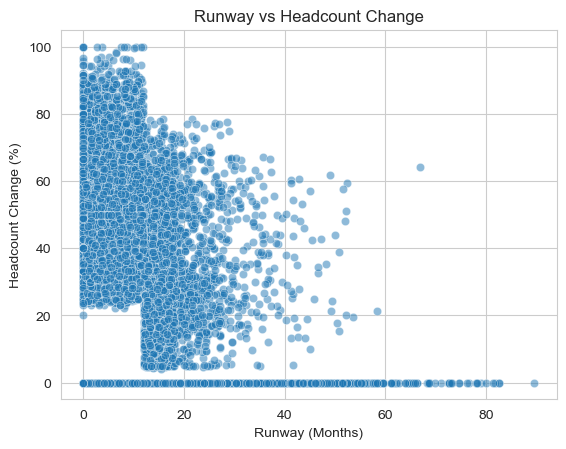

In [45]:
sns.scatterplot(
    data=df,
    x='Runway_Months_2024',
    y='Headcount_Change_Pct',
    alpha=0.5
)

plt.title('Runway vs Headcount Change')
plt.xlabel('Runway (Months)')
plt.ylabel('Headcount Change (%)')
plt.show()

The pattern on the graph is consistent with the Spearman results, which reinforces the point that longer runway equals larger headcount reduction.

In [46]:
from scipy.stats import mannwhitneyu

decreased = df[df['Headcount_Direction'] == 'Decreased']['Runway_Months_2024']
no_change = df[df['Headcount_Direction'] == 'No change']['Runway_Months_2024']

stat, p = mannwhitneyu(
    decreased,
    no_change,
    alternative='two-sided'
)

print('Decreased headcount - median runway: ', decreased.median())
print('No change - median runway: ', no_change.median())
print('Mann-Whitney U statistic: ', stat)
print('p-value: ', p)

Decreased headcount - median runway:  9.6
No change - median runway:  11.7
Mann-Whitney U statistic:  61321926.0
p-value:  3.1481392095176915e-119


The results show that the headcount decreased median runway is 9.6 months, and no headcount change median runway is 11.7 months, leading to a median difference of 2.1 months. In the Mann-Whitney U test, the p-value is less than 0.05, which means there is strong statistical siginificance that the runway distributions differ between startups that reduced headcount and those that did not. The Spearman result from earlier, which was -0.204, could indicate a negative association of modest strength.
Overall, runway was negatively associated with headcount reduction. Startups that reduced headcount had a lower median runway than startups with no reported headcount change.

In [47]:
import statsmodels.formula.api as smf

analysis_df = df.dropna(subset=['AI_Adoption_Level']).copy()

analysis_df['Headcount_Decreased'] = (
    analysis_df['Headcount_Direction'] == 'Decreased'
).astype(int)

In [48]:
model = smf.logit(
    'Headcount_Decreased ~ C(AI_Adoption_Level) + Runway_Months_2024',
    data=analysis_df
).fit()

Optimization terminated successfully.
         Current function value: 0.650198
         Iterations 5


In [49]:
print(model.summary())

                            Logit Regression Results                           
Dep. Variable:     Headcount_Decreased   No. Observations:                22408
Model:                           Logit   Df Residuals:                    22404
Method:                            MLE   Df Model:                            3
Date:                 Sat, 03 Oct 2026   Pseudo R-squ.:                 0.02647
Time:                         17:03:38   Log-Likelihood:                -14570.
converged:                        True   LL-Null:                       -14966.
Covariance Type:             nonrobust   LLR p-value:                1.917e-171
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          0.0354      0.027      1.299      0.194      -0.018       0.089
C(AI_Adoption_Level)[T.Low]       -0.0316      0.036     -0.873

In [50]:
print(np.exp(model.params))

Intercept                         1.036018
C(AI_Adoption_Level)[T.Low]       0.968925
C(AI_Adoption_Level)[T.Medium]    0.998189
Runway_Months_2024                0.959255
dtype: float64


After performing a logistic regression on specific variables, such as AI adoption levels and Runway months, we can conclude that AI adoption levels were not significantly associated with startup headcount reduction. In contrast, runway showed a statistically significant negative association with the likelihood of headcount reduction. However, the model had a low pseudo-R squared, indicating that runway and AI adoption explain only a small proportion of the variation in headcount reduction.

In [51]:
results = pd.DataFrame({
    'Odds Ratio': np.exp(model.params),
    'CI Lower': np.exp(model.conf_int()[0]),
    'CI Upper': np.exp(model.conf_int()[1]),
    'p-value': model.pvalues
})

print(results)

                                Odds Ratio  CI Lower  CI Upper        p-value
Intercept                         1.036018  0.982158  1.092832   1.939347e-01
C(AI_Adoption_Level)[T.Low]       0.968925  0.902663  1.040052   3.824365e-01
C(AI_Adoption_Level)[T.Medium]    0.998189  0.937563  1.062736   9.547912e-01
Runway_Months_2024                0.959255  0.956320  0.962200  6.895135e-156


In [52]:
df.dtypes

Company_ID                     object
Domain                         object
Founding_Year                   int64
Country                        object
City                           object
Funding_Stage                  object
Total_Funding_USD_Millions    float64
Valuation_USD_Millions        float64
Revenue_ARR_Millions          float64
Monthly_Burn_Rate_Millions    float64
Runway_Months_2024            float64
Peak_Headcount_2023             int64
Layoffs_2024_2025               int64
Current_Headcount_2026          int64
Investor_Tier                  object
AI_Adoption_Level              object
Acquisition_Status             object
Headcount_Change_Pct          float64
Headcount_Direction            object
dtype: object

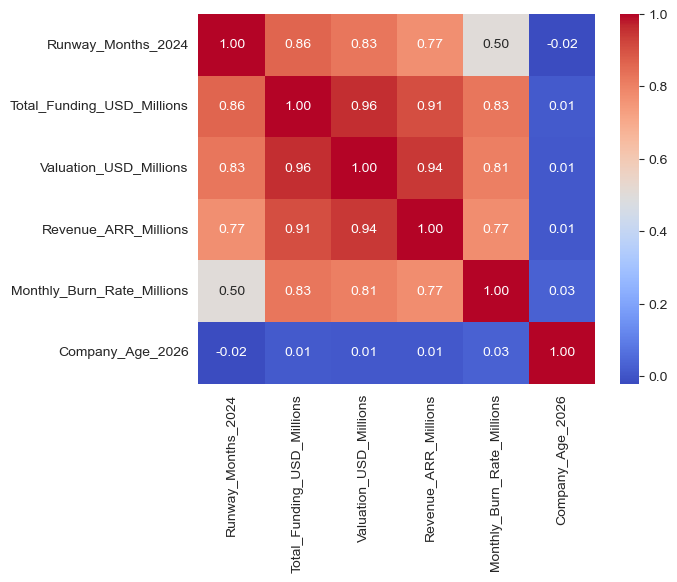

In [53]:
df['Company_Age_2026'] = 2026 - df['Founding_Year']

financial_years = [
    'Runway_Months_2024',
    'Total_Funding_USD_Millions',
    'Valuation_USD_Millions',
    'Revenue_ARR_Millions',
    'Monthly_Burn_Rate_Millions',
    'Company_Age_2026'
]

correlation_matrix = df[financial_years].corr(method='spearman')

sns.heatmap(data=correlation_matrix, cmap='coolwarm', annot=True, fmt='.2f')
plt.show()

In [54]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = df[
    [
        'Runway_Months_2024',
        'Total_Funding_USD_Millions',
        'Valuation_USD_Millions',
        'Revenue_ARR_Millions',
        'Monthly_Burn_Rate_Millions',
        'Company_Age_2026'
    ]
].copy()

In [55]:
log_vars = [
    'Total_Funding_USD_Millions',
    'Valuation_USD_Millions',
    'Revenue_ARR_Millions',
    'Monthly_Burn_Rate_Millions'
]

for col in log_vars:
    vif_df[col] = np.log1p(vif_df[col])

In [56]:
# Removing any possible postive or negative infinite values
vif_df = vif_df.replace([np.inf, -np.inf], np.nan).dropna()

In [57]:
vif_results = pd.DataFrame({
    'Variable': vif_df.columns,
    'VIF': [
        variance_inflation_factor(vif_df.values, i)
        for i in range(vif_df.shape[1])
    ]
})

print(vif_results.sort_values('VIF', ascending=False))

                     Variable        VIF
1  Total_Funding_USD_Millions  68.956557
2      Valuation_USD_Millions  38.442189
3        Revenue_ARR_Millions  31.086610
4  Monthly_Burn_Rate_Millions  23.421352
0          Runway_Months_2024  12.983229
5            Company_Age_2026   6.762250


When using VIF, before committing to using regression, if the results show a value greater than 10, then it shows severe multicollinearity. This means that these variables cannot be considered independent from one another when building a model. In this case, only Company_Age_2026 should be considered despite the result being greater than 5.

In [58]:
vif_df = df[
    [
        'Runway_Months_2024',
        'Company_Age_2026'
    ]
].copy()

vif_df = vif_df.replace([np.inf, -np.inf], np.nan).dropna()

vif_results = pd.DataFrame({
    'Variable': vif_df.columns,
    'VIF': [
        variance_inflation_factor(vif_df.values, i)
        for i in range(vif_df.shape[1])
    ]
})

print(vif_results)

             Variable       VIF
0  Runway_Months_2024  1.974278
1    Company_Age_2026  1.974278


In [59]:
analysis_df = df.dropna(
    subset=[
        'AI_Adoption_Level',
        'Runway_Months_2024',
        'Company_Age_2026'
    ]
).copy()

analysis_df['Headcount_Decreased'] = (
    analysis_df['Headcount_Direction'] == 'Decreased'
).astype(int)

model_2 = smf.logit(
    'Headcount_Decreased ~ C(AI_Adoption_Level) + '
    'Runway_Months_2024 + Company_Age_2026',
    data=analysis_df
).fit()

print(model_2.summary())

Optimization terminated successfully.
         Current function value: 0.649473
         Iterations 5
                            Logit Regression Results                           
Dep. Variable:     Headcount_Decreased   No. Observations:                22408
Model:                           Logit   Df Residuals:                    22403
Method:                            MLE   Df Model:                            4
Date:                 Sat, 03 Oct 2026   Pseudo R-squ.:                 0.02756
Time:                         17:03:39   Log-Likelihood:                -14553.
converged:                        True   LL-Null:                       -14966.
Covariance Type:             nonrobust   LLR p-value:                3.090e-177
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -0.1693      0.045     -3.

In [60]:
results_2 = pd.DataFrame({
    'Odds Ratio': np.exp(model_2.params),
    'CI Lower': np.exp(model_2.conf_int()[0]),
    'CI Upper': np.exp(model_2.conf_int()[1]),
    'p-value': model_2.pvalues
})

print(results_2)

                                Odds Ratio  CI Lower  CI Upper        p-value
Intercept                         0.844227  0.772861  0.922182   1.714519e-04
C(AI_Adoption_Level)[T.Low]       0.969446  0.903106  1.040658   3.908888e-01
C(AI_Adoption_Level)[T.Medium]    1.000226  0.939429  1.064957   9.943693e-01
Runway_Months_2024                0.959400  0.956454  0.962355  8.664959e-154
Company_Age_2026                  1.028757  1.018783  1.038830   1.174558e-08


So far, the interpretation is that each additional month of runway is associated with approximately 4.1% (1 - odds ratio of 0.959) lower odds of headcount decrease, while holding AI adoption level and company age as constants.
Company age is also significant, as it shows that each additional year of company age is associated with approximately 2.9% (1.0287 of odds ratio - 1) higher odds of a headcount decrease, while hodling AI adoption and runway as constants.

In [61]:
print('Funding Stage:')
print(df['Funding_Stage'].value_counts(dropna=False))

print('\nInvestor Tier:')
print(df['Investor_Tier'].value_counts(dropna=False))

Funding Stage:
Funding_Stage
Seed         8859
Series A     6154
Series B     5014
Series C+    2996
Pre-IPO      1257
Post-IPO      720
Name: count, dtype: int64

Investor Tier:
Investor_Tier
Tier 3 (Angel/Seed)                    9965
Tier 2 (Mid-size VC)                   7477
Corporate VC (e.g. Google Ventures)    3839
Tier 1 (e.g. Sequoia, a16z)            2544
Bootstrapped                           1175
Name: count, dtype: int64


In [62]:
model_funding = smf.logit(
    'Headcount_Decreased ~ C(AI_Adoption_Level) +'
    'Runway_Months_2024 + Company_Age_2026 + C(Funding_Stage)',
    data=analysis_df
).fit()

print(model_funding.summary())

Optimization terminated successfully.
         Current function value: 0.636213
         Iterations 5
                            Logit Regression Results                           
Dep. Variable:     Headcount_Decreased   No. Observations:                22408
Model:                           Logit   Df Residuals:                    22398
Method:                            MLE   Df Model:                            9
Date:                 Sat, 03 Oct 2026   Pseudo R-squ.:                 0.04741
Time:                         17:03:39   Log-Likelihood:                -14256.
converged:                        True   LL-Null:                       -14966.
Covariance Type:             nonrobust   LLR p-value:                5.549e-300
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          1.1237      0.105     10.

In [63]:
model_investor = smf.logit(
    'Headcount_Decreased ~ C(AI_Adoption_Level) +'
    'Runway_Months_2024 + Company_Age_2026 + C(Investor_Tier)',
    data=analysis_df
).fit()

print(model_investor.summary())

Optimization terminated successfully.
         Current function value: 0.648000
         Iterations 5
                            Logit Regression Results                           
Dep. Variable:     Headcount_Decreased   No. Observations:                22408
Model:                           Logit   Df Residuals:                    22399
Method:                            MLE   Df Model:                            8
Date:                 Sat, 03 Oct 2026   Pseudo R-squ.:                 0.02977
Time:                         17:03:39   Log-Likelihood:                -14520.
converged:                        True   LL-Null:                       -14966.
Covariance Type:             nonrobust   LLR p-value:                5.080e-187
                                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept 

In [64]:
from scipy.stats import chi2

lr_funding = 2 * (model_funding.llf - model_2.llf)
df_funding = model_funding.df_model - model_2.df_model
p_funding = chi2.sf(lr_funding, df_funding)

print('Funding Stage comparison')
print('LR statistic: ', lr_funding)
print('Degrees of Freedom: ', df_funding)
print('p-value: ', p_funding)

lr_investor = 2 * (model_investor.llf - model_2.llf)
df_investor = model_investor.df_model - model_2.df_model
p_investor = chi2.sf(lr_investor, df_investor)

print('\nInvestor Tier comparison')
print('LR statistic: ', lr_investor)
print('Degrees of Freedom: ', df_investor)
print('p-value: ', p_investor)

Funding Stage comparison
LR statistic:  594.2711649797639
Degrees of Freedom:  5.0
p-value:  3.496572167552324e-126

Investor Tier comparison
LR statistic:  66.03297912725975
Degrees of Freedom:  4.0
p-value:  1.5588713089740761e-13


In [65]:
print('Funding Stage:')
print(df['Funding_Stage'].value_counts())

print('\nFunding Stage categories:')
print(df['Funding_Stage'].unique())

print('\nInvestor Tier:')
print(df['Investor_Tier'].value_counts())

print('\nInvestor Tier categories:')
print(df['Investor_Tier'].unique())

Funding Stage:
Funding_Stage
Seed         8859
Series A     6154
Series B     5014
Series C+    2996
Pre-IPO      1257
Post-IPO      720
Name: count, dtype: int64

Funding Stage categories:
['Seed' 'Pre-IPO' 'Series A' 'Series B' 'Series C+' 'Post-IPO']

Investor Tier:
Investor_Tier
Tier 3 (Angel/Seed)                    9965
Tier 2 (Mid-size VC)                   7477
Corporate VC (e.g. Google Ventures)    3839
Tier 1 (e.g. Sequoia, a16z)            2544
Bootstrapped                           1175
Name: count, dtype: int64

Investor Tier categories:
['Tier 3 (Angel/Seed)' 'Tier 2 (Mid-size VC)'
 'Corporate VC (e.g. Google Ventures)' 'Tier 1 (e.g. Sequoia, a16z)'
 'Bootstrapped']


In [66]:
print('Model 2 AIC: ', model_2.aic)
print('Funding Stage Model AIC: ', model_funding.aic)
print('Investor Tier Model AIC: ', model_investor.aic)

Model 2 AIC:  29116.781057375607
Funding Stage Model AIC:  28532.509892395843
Investor Tier Model AIC:  29058.748078248347


The AIC for Funding Stage Model is lower, and the same is seen for Investor Tier Model, which means that both model improve on the second model.

In [67]:
model_final = smf.logit(
    'Headcount_Decreased ~ C(AI_Adoption_Level) + '
    'Runway_Months_2024 + Company_Age_2026 +'
    'C(Funding_Stage) + C(Investor_Tier)',
    data=analysis_df
).fit()

print(model_final.summary())

Optimization terminated successfully.
         Current function value: 0.630988
         Iterations 6
                            Logit Regression Results                           
Dep. Variable:     Headcount_Decreased   No. Observations:                22408
Model:                           Logit   Df Residuals:                    22394
Method:                            MLE   Df Model:                           13
Date:                 Sat, 03 Oct 2026   Pseudo R-squ.:                 0.05524
Time:                         17:03:40   Log-Likelihood:                -14139.
converged:                        True   LL-Null:                       -14966.
Covariance Type:             nonrobust   LLR p-value:                     0.000
                                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept 

In [68]:
results_final = pd.DataFrame({
    'Odds Ratio': np.exp(model_final.params),
    'CI Lower': np.exp(model_final.conf_int()[0]),
    'CI Upper': np.exp(model_final.conf_int()[1]),
    'p-value': model_final.pvalues
})

print(results_final)
print('\nAIC: ', model_final.aic)
print('McFadden pseudo-R squared: ', model_final.prsquared)

                                                    Odds Ratio  CI Lower  \
Intercept                                             1.547033  1.232921   
C(AI_Adoption_Level)[T.Low]                           0.965755  0.898530   
C(AI_Adoption_Level)[T.Medium]                        0.983061  0.922275   
C(Funding_Stage)[T.Pre-IPO]                           0.863805  0.699650   
C(Funding_Stage)[T.Seed]                              0.197756  0.163322   
C(Funding_Stage)[T.Series A]                          0.340216  0.283348   
C(Funding_Stage)[T.Series B]                          0.536944  0.448057   
C(Funding_Stage)[T.Series C+]                         0.711485  0.590051   
C(Investor_Tier)[T.Corporate VC (e.g. Google Ve...    2.647534  2.262414   
C(Investor_Tier)[T.Tier 1 (e.g. Sequoia, a16z)]       3.340165  2.818752   
C(Investor_Tier)[T.Tier 2 (Mid-size VC)]              2.906019  2.504032   
C(Investor_Tier)[T.Tier 3 (Angel/Seed)]               2.910001  2.512466   
Runway_Month

In [69]:
lr_investor_final = 2 * (
    model_final.llf - model_funding.llf
)

df_investor_final = (
    model_final.df_model - model_funding.df_model
)

p_investor_final = chi2.sf(
    lr_investor_final,
    df_investor_final
)

print('LR statistic: ', lr_investor_final)
print('Degrees of freedom: ', df_investor_final)
print('p-value: ', p_investor_final)

LR statistic:  234.16603928951372
Degrees of freedom:  4.0
p-value:  1.6737018424290113e-49


In [70]:
X = model_final.model.exog
names = model_final.model.exog_names

vif_final = pd.DataFrame({
    'Variable': names,
    'VIF': [
        variance_inflation_factor(X, i)
        for i in range(X.shape[1])
    ]
})

print(vif_final)

                                             Variable        VIF
0                                           Intercept  64.782598
1                         C(AI_Adoption_Level)[T.Low]   1.174268
2                      C(AI_Adoption_Level)[T.Medium]   1.174733
3                         C(Funding_Stage)[T.Pre-IPO]   2.599537
4                            C(Funding_Stage)[T.Seed]   9.931802
5                        C(Funding_Stage)[T.Series A]   7.522393
6                        C(Funding_Stage)[T.Series B]   6.410796
7                       C(Funding_Stage)[T.Series C+]   4.505960
8   C(Investor_Tier)[T.Corporate VC (e.g. Google V...   3.982995
9     C(Investor_Tier)[T.Tier 1 (e.g. Sequoia, a16z)]   3.214223
10           C(Investor_Tier)[T.Tier 2 (Mid-size VC)]   5.771110
11            C(Investor_Tier)[T.Tier 3 (Angel/Seed)]   6.372531
12                                 Runway_Months_2024   1.877663
13                                   Company_Age_2026   1.009073


There are moderate multicollinearity among some funding-stage and investor-tier categories, while AI adoption, runway, and company age showed low multicollinearity.
It is possible that Funding Stage and Investor Tier may have some overlapping aspects of a startup's financing.

In [71]:
funding_investor_table = pd.crosstab(
    df['Funding_Stage'],
    df['Investor_Tier']
)

In [72]:
chi2_stat, p, dof, expected = chi2_contingency(
    funding_investor_table
)

n = funding_investor_table.to_numpy().sum()
r, k = funding_investor_table.shape

cramers_v = np.sqrt(
    chi2_stat / (n * min(k - 1, r - 1))
)

print('Chi-square: ', chi2_stat)
print('p-value: ', p)
print('Cramer\'s V: ', cramers_v)

Chi-square:  28.025573420583246
p-value:  0.10879537434236004
Cramer's V:  0.01674084030763786


The p-value is greater than 0.05, which means there is little evidence that an association exists between funding stage and investor tier. This is further proved by the Cramer's V (0.017), which indicates independence between the two variables.

### Conclusion

The analysis found no statisitcally significant association between AI adoption level and startup headcount reduction. This finding remained consistent across descriptive comparisons, a Kruskall-Wallis test, a chi-square test, and multivariate logistic regression. In contrast, runway, company age, funding stage, and investor tier were statistically associated with the likelihood of a headcount decrease. In particular, longer runway was associated with lower odds of headcount reduction, while older company age was associated with higher odds. However, the final model had a relatively low McFadden pseudo-R squared of 0.055, indicating that the included variables explain only a limited proportion of the variation in headcount reduction.
Therefore, the dataset provides evidence of associations between several startup characteristics and headcount reduction, but it does not establish that these characteristics, including AI adoption, caused the observed changes.